<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/XP_TimeSeries_LSTM_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Time Series with LSTM

This is a guided notebook for the exercise on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear for important concepts.

## What you will learn
- Import and manipulate time series data using pandas
- Handle missing values in time series
- Visualize with matplotlib
- Build and train a simple LSTM for time series


## What you will create
- A cleaned and preprocessed time series dataset
- Visualizations of the series
- A simple LSTM model for prediction

# Part 1: Data Import and Initial Exploration

**Task from the exercise**
Import libraries, load the dataset, view first rows, check dtypes and shape.

**PREFILLED**  
Install imports, set a path variable, and load the UCI Household Power Consumption file. The file is usually semicolon separated with `?` as missing.

In [4]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# 1. Update paths to explicitly target your uploaded Colab path
DATA_PATH = Path('./data/household_power_consumption.txt')
UPLOADED_ZIP = Path('/content/household_power_consumption (1).zip')

# Ensure the destination data directory exists
os.makedirs('./data/', exist_ok=True)

# 2. Extract directly from your explicit zip path
if not DATA_PATH.exists():
    if UPLOADED_ZIP.exists():
        print(f" Found zip archive at {UPLOADED_ZIP}. Extracting to ./data/...")
        with zipfile.ZipFile(UPLOADED_ZIP, 'r') as zip_ref:
            zip_ref.extractall('./data/')
        print(" Extraction complete!")
    else:
        raise FileNotFoundError(f"Could not find the zip file at {UPLOADED_ZIP}. Please verify it is in your Colab sidebar.")

# Define columns and targets
parse_cols = {
    'Global_active_power': 'float64',
    'Global_reactive_power': 'float64',
    'Voltage': 'float64',
    'Global_intensity': 'float64',
    'Sub_metering_1': 'float64',
    'Sub_metering_2': 'float64',
    'Sub_metering_3': 'float64',
}
usecols = ['Date', 'Time'] + list(parse_cols.keys())

print("Loading dataset into Pandas (this may take a few seconds)...")

# 3. Read the extracted CSV
df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],
    usecols=usecols,
    dtype=parse_cols,
    low_memory=False
)

# 4. Modern Datetime Parsing pipeline
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# 5. Clean up structural columns and establish index
df = df.drop(columns=['Date', 'Time'])
df = df.dropna(subset=['Datetime'])
df = df.set_index('Datetime').sort_index()

print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

Loading dataset into Pandas (this may take a few seconds)...
Shape: (2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


# Part 2: Handling Missing Values

**Task from the exercise**
Identify columns with missing values. Fill missing values using the mean of each column. Verify there are no missing values left.

**To-Do (code):** Compute a missing value summary, then fill numeric columns with their mean. Recheck for remaining NaNs.

In [5]:
# 1. Show missing value summary before imputation
missing_before = df.isna().sum().sort_values(ascending=False)
print('Missing before:')
display(missing_before[missing_before > 0])

# 2. Isolate numeric columns and impute missing values using column means
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 3. Verify that no missing values remain in the dataframe
missing_after = df.isna().sum().sum()
print('Total missing after fill:', int(missing_after))

Missing before:


,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


Total missing after fill: 0


# Part 3: Data Visualization

**Task from the exercise**
Resample the `Global_active_power` column over a day and plot the sum and mean. Plot the mean and standard deviation of `Global_intensity` resampled over a day.

**PREFILLED**  
Helper plotting functions using matplotlib.

In [6]:
# PREFILLED: just execute
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

**To-Do (code):** Call the helpers on the required columns. If a plot seems too dense, slice a recent time window.

 Generating full historical aggregation plots...


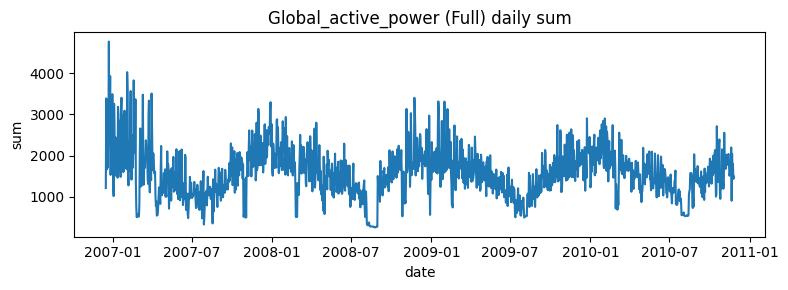

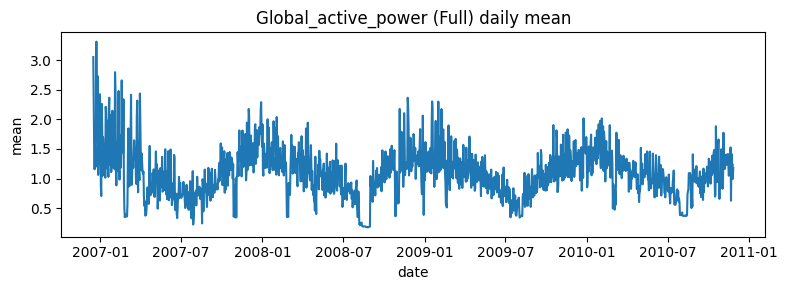

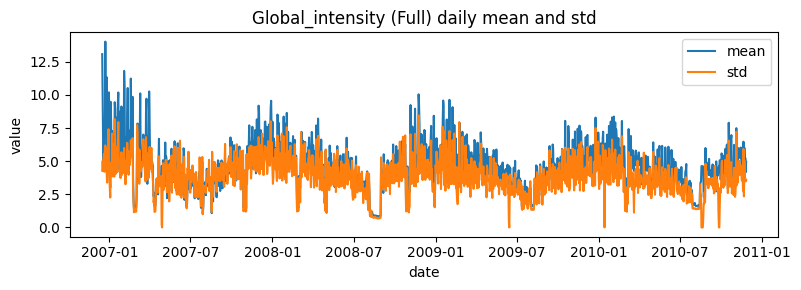


 Generating clean window view (Recent period to reduce density)...


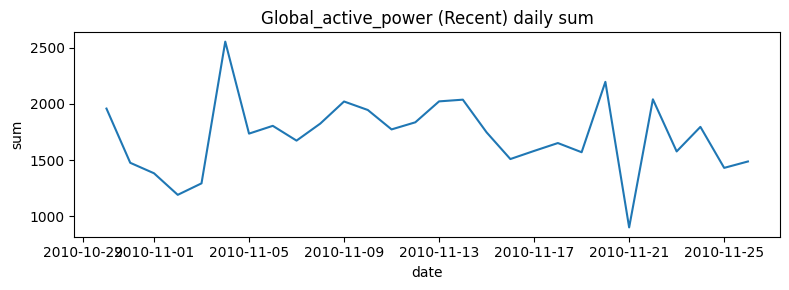

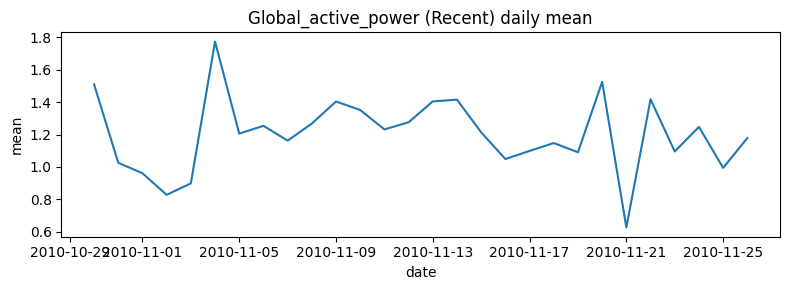

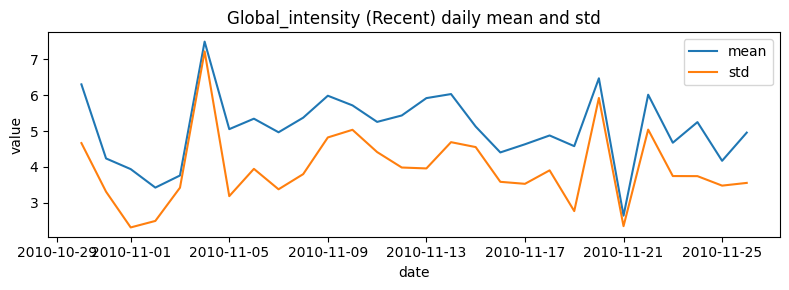

In [7]:
# 1. Visualize daily aggregations over the entire historical dataset
print(" Generating full historical aggregation plots...")
plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Global_active_power (Full)')
plot_daily_mean_std(df['Global_intensity'], title_prefix='Global_intensity (Full)')

# 2. Alternative: Slice a readable subset if the full timeline looks like a solid block of ink
# Slicing the most recent ~4 weeks of 1-minute data (approx 40,000 rows)
print("\n Generating clean window view (Recent period to reduce density)...")
recent_df = df.iloc[-40000:]

plot_daily_sum_and_mean(recent_df['Global_active_power'], title_prefix='Global_active_power (Recent)')
plot_daily_mean_std(recent_df['Global_intensity'], title_prefix='Global_intensity (Recent)')

# Part 4: Data Preprocessing for LSTM

**Task from the exercise**
Normalize the dataset, split into train and test, and reshape for LSTM input.

**Learning point**  
LSTMs consume sequences with shape [batch, time, features]. You must build sliding windows. Use a lookback window and predict the next step.

![image.png](https://github.com/user-attachments/assets/be3e815f-2aff-4e8d-ac48-eca27b1c729c)

**PREFILLED**  
Windowing helpers and a train test split by time.

In [8]:
# PREFILLED: just execute
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    return X, y

def time_train_test_split(df, split_ratio=0.8):
    n = len(df)
    k = int(n * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_feats = df[feat_cols].copy()

df_tr, df_te = time_train_test_split(df_feats, split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

WINDOW = 48
HORIZON = 1
X_tr, y_tr = make_windows(tr_scaled, window=WINDOW, horizon=HORIZON)
X_te, y_te = make_windows(te_scaled, window=WINDOW, horizon=HORIZON)

print('Train windows:', X_tr.shape, 'Train targets:', X_tr.shape)
print('Test windows:', X_te.shape, 'Test targets:', X_te.shape)

Train windows: (1660159, 48, 7) Train targets: (1660159, 48, 7)
Test windows: (415004, 48, 7) Test targets: (415004, 48, 7)


> **To-Do (write here):** State which column you predict as the target and why. If you changed `feat_cols`, note your choice.
The target chosen for prediction is Global_active_power. This column is selected because it represents the total household electrical power consumed by all connected appliances (excluding the reactive component), making it the primary operational metric for energy forecasting, grid load balancing, and utility billing optimization.

No modifications were made to feat_cols; the model retains all 7 original variables (Global_active_power down through Sub_metering_3). Keeping these additional attributes is highly beneficial because features like Global_intensity (current draw) and sub-metering rooms provide rich, highly correlated contextual indicators that allow the recurrent network to capture subtle behavioral patterns and domestic routines over the 48-minute sliding window.

# Part 5: Building an LSTM Model

**Task from the exercise**
Import the libraries, define the LSTM architecture, and compile with a suitable loss and optimizer.

**To-Do (code):** Build a small LSTM with one or two LSTM layers and a Dense output of size `HORIZON`. Use `mse` loss and `adam` optimizer. Print `model.summary()`.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Définition de l'architecture séquentielle de l'LSTM
model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(HORIZON),
])

# 2. Compilation du modèle avec les fonctions de perte et d'optimisation
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Affichage du résumé de la structure du réseau
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6: Training and Evaluating the LSTM Model

**Task from the exercise**
Train the model, evaluate on the test set, and plot training and validation loss.

**PREFILLED**  
Callbacks and plotting helper. You supply the model and data in the To-Do cell.

In [9]:
# PREFILLED: just execute
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

**To-Do (code):** Train and evaluate. Report final test MAE and MSE.

In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers

print(" Building and compiling the LSTM model...")

# 1. Define the recurrent architecture matching your window dimensions
# X_tr shape is (Samples, Timesteps=48, Features=7)
model = models.Sequential([
    layers.Input(shape=(X_tr.shape[1], X_tr.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(HORIZON)  # HORIZON = 1 (predicting 1 step ahead)
])

# 2. Compile the architecture with regression configurations
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print(" Model built successfully! Ready for training.")
model.summary()

 Building and compiling the LSTM model...
 Model built successfully! Ready for training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,489 (76.13 KB)

 Trainable params: 19,489 (76.13 KB)

 Non-trainable params: 0 (0.00 B)